# *Лабораторная работа №2*

Выполнил: Самойловских Алексей  
Группа: M3234  
Вариант: 62

$f(x)=\begin{cases}0, & x\in[0,1);\\2-x, & x\in[1,2].\end{cases}$

### Часть 2. Численный счет

Формулы частичных сумм из аналитической части:

$$S_N^{\text{общ}}(x)=\frac14+\sum_{k=1}^{N}\left(\frac{1-(-1)^k}{\pi^2k^2}\cos(\pi k(x-1))+\frac{1}{\pi k}\sin(\pi k(x-1))\right).$$

$$S_N^{\sin}(x)=\sum_{k=1}^{N}(-1)^k\left(\frac{2\cos\frac{\pi k}{2}}{\pi k}-\frac{4\sin\frac{\pi k}{2}}{\pi^2k^2}\right)\sin\frac{\pi kx}{2}.$$

$$S_N^{\cos}(x)=\frac14+\sum_{k=1}^{N}(-1)^k\left(\frac{2\sin\frac{\pi k}{2}}{\pi k}+\frac{4\left(\cos\frac{\pi k}{2}-1\right)}{\pi^2k^2}\right)\cos\frac{\pi kx}{2}.$$

На графиках беру несколько периодов: для общего ряда $T=2$, для рядов по синусам и косинусам $T=4$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Исходная функция на [0, 2]
def f(x):
    x = np.asarray(x, dtype=float)
    return np.where(x < 1, 0, 2 - x)


# Частичная сумма общего ряда Фурье
def s_general(x, n):
    x = np.asarray(x, dtype=float)
    k = np.arange(1, n + 1)[:, None]
    x_grid = x[None, :]
    a_k = (1 - (-1) ** k) / (np.pi ** 2 * k ** 2)
    b_k = 1 / (np.pi * k)
    return 1 / 4 + np.sum(
        a_k * np.cos(np.pi * k * (x_grid - 1)) +
        b_k * np.sin(np.pi * k * (x_grid - 1)),
        axis=0
    )


# Частичная сумма ряда по синусам
def s_sin(x, n):
    x = np.asarray(x, dtype=float)
    k = np.arange(1, n + 1)[:, None]
    x_grid = x[None, :]
    b_k = (-1) ** k * (
        2 * np.cos(np.pi * k / 2) / (np.pi * k) -
        4 * np.sin(np.pi * k / 2) / (np.pi ** 2 * k ** 2)
    )
    return np.sum(b_k * np.sin(np.pi * k * x_grid / 2), axis=0)


# Частичная сумма ряда по косинусам
def s_cos(x, n):
    x = np.asarray(x, dtype=float)
    k = np.arange(1, n + 1)[:, None]
    x_grid = x[None, :]
    a_k = (-1) ** k * (
        2 * np.sin(np.pi * k / 2) / (np.pi * k) +
        4 * (np.cos(np.pi * k / 2) - 1) / (np.pi ** 2 * k ** 2)
    )
    return 1 / 4 + np.sum(a_k * np.cos(np.pi * k * x_grid / 2), axis=0)


def f_general_periodic(x):
    x = np.asarray(x, dtype=float)
    x_period = x % 2
    return np.where(x_period < 1, 0, 2 - x_period)


def f_cos_periodic(x):
    x = np.asarray(x, dtype=float)
    x_period = ((x + 2) % 4) - 2
    u = np.abs(x_period)
    return np.where(u < 1, 0, 2 - u)


def f_sin_periodic(x):
    x = np.asarray(x, dtype=float)
    x_period = ((x + 2) % 4) - 2
    u = np.abs(x_period)
    return np.sign(x_period) * np.where(u < 1, 0, 2 - u)


def plot_sum_reference(func, x_min, x_max, break_points, point_x, point_y, label):
    points = [x_min] + [p for p in break_points if x_min < p < x_max] + [x_max]
    x_plot = []
    y_plot = []

    for left, right in zip(points[:-1], points[1:]):
        x_part = np.linspace(left, right, 500)
        if left in break_points:
            x_part[0] = np.nan
        if right in break_points:
            x_part[-1] = np.nan

        y_part = func(x_part)
        x_plot.extend(x_part)
        y_plot.extend(y_part)
        x_plot.append(np.nan)
        y_plot.append(np.nan)

    plt.plot(x_plot, y_plot, color='black', linewidth=2.5, label=label)
    plt.scatter(point_x, point_y, color='black', s=28, zorder=6)


def setup_axes(title, x_min, x_max, y_min, y_max, x_ticks, y_ticks, period_bounds):
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xticks(x_ticks)
    plt.yticks(y_ticks)
    plt.axhline(0, color='gray', linewidth=1, alpha=0.7)
    for i, bound in enumerate(period_bounds):
        plt.axvline(
            bound,
            color='gray',
            linestyle=':',
            linewidth=1,
            alpha=0.8,
            label='границы периодов' if i == 0 else None
        )
    plt.grid(True)

### 1. Общий ряд Фурье

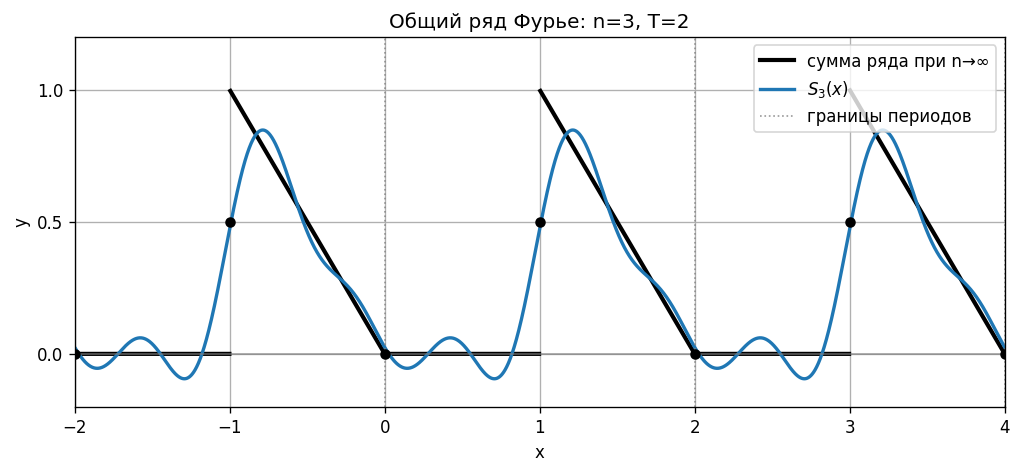

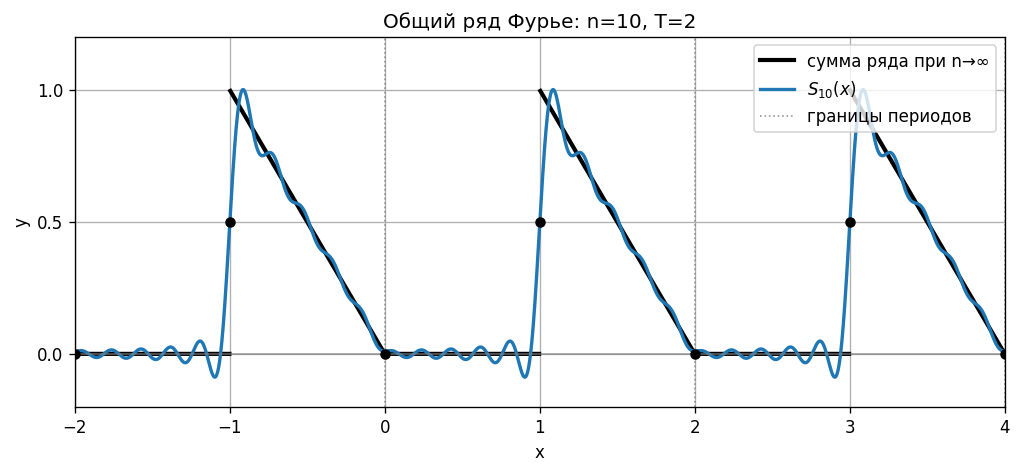

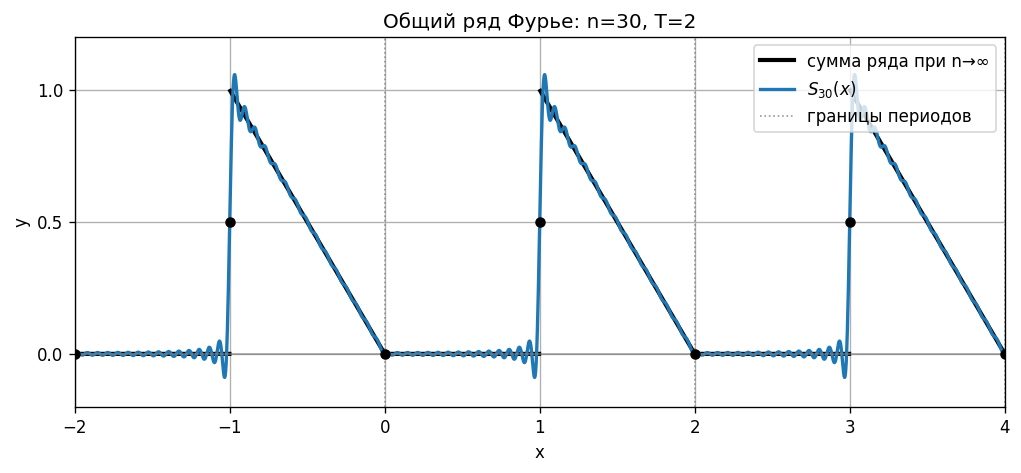

In [3]:
x_general = np.linspace(-2, 4, 7000)
values = [3, 10, 30]

for n in values:
    plt.figure(figsize=(10, 4))
    plot_sum_reference(
        f_general_periodic,
        -2,
        4,
        break_points=[-1, 1, 3],
        point_x=[-2, -1, 0, 1, 2, 3, 4],
        point_y=[0, 1 / 2, 0, 1 / 2, 0, 1 / 2, 0],
        label='сумма ряда при n→∞'
    )
    plt.plot(x_general, s_general(x_general, n), label=fr'$S_{{{n}}}(x)$', linewidth=2)
    setup_axes(
        f'Общий ряд Фурье: n={n}, T=2',
        -2,
        4,
        -0.2,
        1.2,
        x_ticks=[-2, -1, 0, 1, 2, 3, 4],
        y_ticks=[0, 0.5, 1],
        period_bounds=[-2, 0, 2, 4]
    )
    plt.legend(loc='upper right')
    plt.show()

### 2. Ряд по синусам

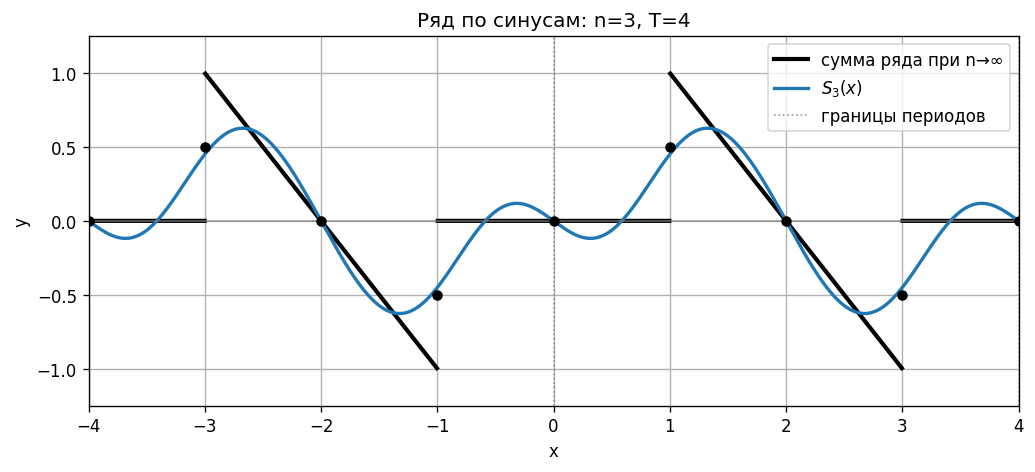

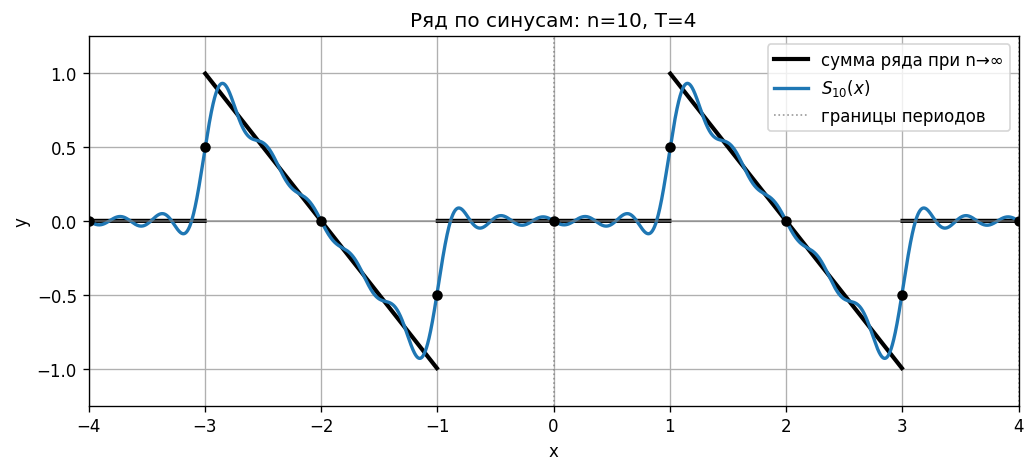

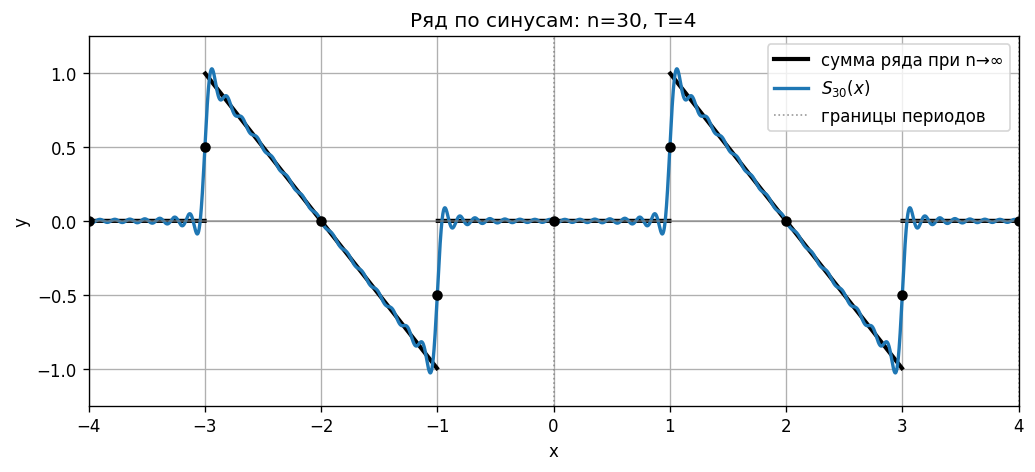

In [4]:
x_trig = np.linspace(-4, 4, 9000)

for n in values:
    plt.figure(figsize=(10, 4))
    plot_sum_reference(
        f_sin_periodic,
        -4,
        4,
        break_points=[-3, -1, 1, 3],
        point_x=[-4, -3, -2, -1, 0, 1, 2, 3, 4],
        point_y=[0, 1 / 2, 0, -1 / 2, 0, 1 / 2, 0, -1 / 2, 0],
        label='сумма ряда при n→∞'
    )
    plt.plot(x_trig, s_sin(x_trig, n), label=fr'$S_{{{n}}}(x)$', linewidth=2)
    setup_axes(
        f'Ряд по синусам: n={n}, T=4',
        -4,
        4,
        -1.25,
        1.25,
        x_ticks=[-4, -3, -2, -1, 0, 1, 2, 3, 4],
        y_ticks=[-1, -0.5, 0, 0.5, 1],
        period_bounds=[-4, 0, 4]
    )
    plt.legend(loc='upper right')
    plt.show()

### 3. Ряд по косинусам

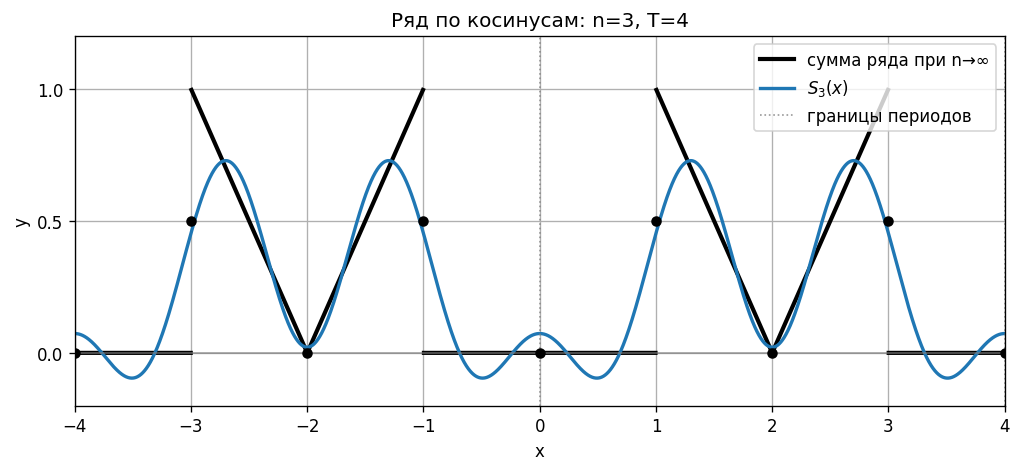

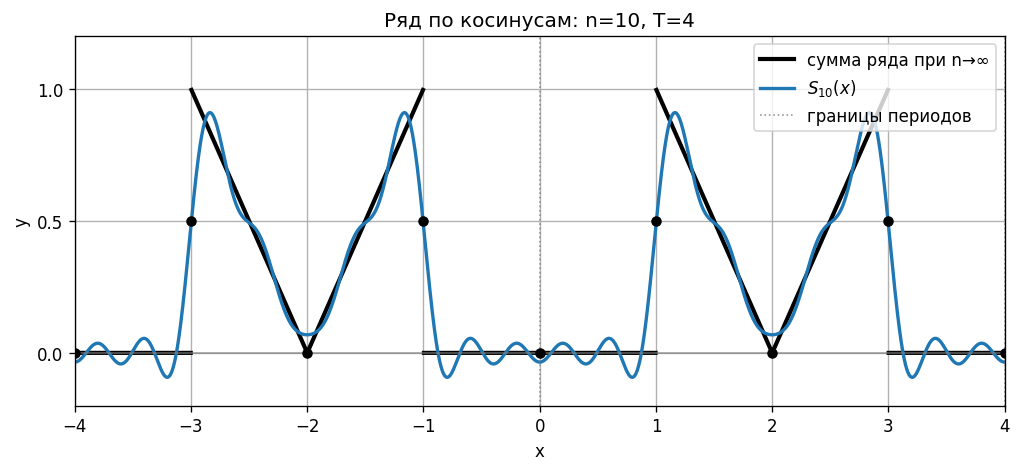

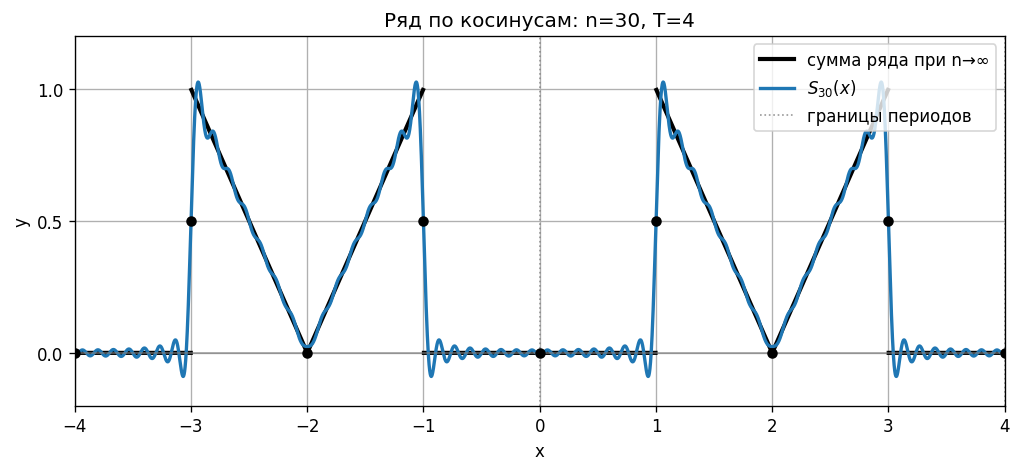

In [5]:
for n in values:
    plt.figure(figsize=(10, 4))
    plot_sum_reference(
        f_cos_periodic,
        -4,
        4,
        break_points=[-3, -1, 1, 3],
        point_x=[-4, -3, -2, -1, 0, 1, 2, 3, 4],
        point_y=[0, 1 / 2, 0, 1 / 2, 0, 1 / 2, 0, 1 / 2, 0],
        label='сумма ряда при n→∞'
    )
    plt.plot(x_trig, s_cos(x_trig, n), label=fr'$S_{{{n}}}(x)$', linewidth=2)
    setup_axes(
        f'Ряд по косинусам: n={n}, T=4',
        -4,
        4,
        -0.2,
        1.2,
        x_ticks=[-4, -3, -2, -1, 0, 1, 2, 3, 4],
        y_ticks=[0, 0.5, 1],
        period_bounds=[-4, 0, 4]
    )
    plt.legend(loc='upper right')
    plt.show()

### Вывод:  
Я построил графики частичных сумм общего ряда Фурье, ряда по синусам и ряда по косинусам при $n=3,10,30$.   
Общий ряд имеет период $T=2$, ряд по косинусам является четным продолжением с периодом $T=4$, а ряд по синусам является нечетным продолжением с периодом $T=4$.  

По теореме Дирихле сумма ряда в точках непрерывности совпадает с соответствующим продолжением исходной функции. В точках скачка сумма ряда равна полусумме односторонних пределов:
$$
S(x_0)=\frac{f(x_0-0)+f(x_0+0)}{2}.
$$

Например, в точке x=1:
$$
S(1)=\frac{f(1-0)+f(1+0)}{2}
=\frac{0+1}{2}
=\frac12,
$$
хотя исходная функция задана так, что $$f(1)=1$$

По графикам видно, что при увеличении числа слагаемых \(n\) частичные суммы всё лучше приближают сумму ряда. В окрестностях точек скачка появляются колебания, что является характерным поведением частичных сумм рядов Фурье. 
#### ***Спасибо за проверку работы &#10084;***